In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [40]:
import pandas as pd

X_train = pd.read_csv(
r"C:\Users\rrasu\Desktop\Hotel-Booking-Cancellation-Prediction\Data\SMOTE_Data\X_train_selected_smote.csv"
)

y_train = pd.read_csv(
r"C:\Users\rrasu\Desktop\Hotel-Booking-Cancellation-Prediction\Data\SMOTE_Data\y_train_smote.csv"
)

X_test = pd.read_csv(
r"C:\Users\rrasu\Desktop\Hotel-Booking-Cancellation-Prediction\Data\Feature_Selection\X_test_selected.csv"
)

y_test = pd.read_csv(
r"C:\Users\rrasu\Desktop\Hotel-Booking-Cancellation-Prediction\Data\Preprosessed\y_test.csv"
)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(120518, 34)
(23878, 34)
(120518, 1)
(23878, 1)


In [42]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

# Tensorga convert qilish

In [43]:
import torch

# pandas -> numpy
X_train_np = X_train.values
X_val_np = X_val.values
X_test_np = X_test.values

y_train_np = y_train.values
y_val_np = y_val.values
y_test_np = y_test.values


# numpy -> torch tensor
X_train_t = torch.tensor(X_train_np, dtype=torch.float32)
y_train_t = torch.tensor(y_train_np, dtype=torch.float32).view(-1, 1)

X_val_t = torch.tensor(X_val_np, dtype=torch.float32)
y_val_t = torch.tensor(y_val_np, dtype=torch.float32).view(-1, 1)

X_test_t = torch.tensor(X_test_np, dtype=torch.float32)
y_test_t = torch.tensor(y_test_np, dtype=torch.float32).view(-1, 1)

# Data Loaders

In [44]:
from torch.utils.data import TensorDataset, DataLoader
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [45]:
print(len(train_loader))
print(len(val_loader))
print(len(test_loader))

3390
377
747


In [46]:
for X_batch, y_batch in train_loader:
    print(X_batch.shape)
    print(y_batch.shape)
    break

torch.Size([32, 34])
torch.Size([32, 1])


# Model set up

In [47]:
import torch
import torch.nn as nn

class StructuredNN(nn.Module):

    def __init__(self, input_dim):
        super(StructuredNN, self).__init__()

        self.net = nn.Sequential(

            nn.Linear(input_dim, 32),   
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, 16),          
            nn.ReLU(),

            nn.Linear(16, 1)           
        )

    def forward(self, x):
        return self.net(x)

# Loss va optimizer

In [48]:
input_dim = X_train_t.shape[1]

model = StructuredNN(input_dim)

In [49]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

# Training

In [50]:
import torch
import torch.optim as optim
import torch.nn as nn

num_epochs = 50

train_losses = []
val_losses = []

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(num_epochs):

    # ===== TRAIN =====
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)

    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            val_loss += loss.item() * X_batch.size(0)

    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

Epoch [1/50] | Train Loss: 0.5221 | Val Loss: 0.4261
Epoch [2/50] | Train Loss: 0.4380 | Val Loss: 0.3993
Epoch [3/50] | Train Loss: 0.4191 | Val Loss: 0.3821
Epoch [4/50] | Train Loss: 0.4086 | Val Loss: 0.3926
Epoch [5/50] | Train Loss: 0.4008 | Val Loss: 0.3759
Epoch [6/50] | Train Loss: 0.3952 | Val Loss: 0.3773
Epoch [7/50] | Train Loss: 0.3937 | Val Loss: 0.3717
Epoch [8/50] | Train Loss: 0.3918 | Val Loss: 0.3695
Epoch [9/50] | Train Loss: 0.3870 | Val Loss: 0.3670
Epoch [10/50] | Train Loss: 0.3849 | Val Loss: 0.3662
Epoch [11/50] | Train Loss: 0.3836 | Val Loss: 0.3662
Epoch [12/50] | Train Loss: 0.3814 | Val Loss: 0.3589
Epoch [13/50] | Train Loss: 0.3799 | Val Loss: 0.3592
Epoch [14/50] | Train Loss: 0.3785 | Val Loss: 0.3594
Epoch [15/50] | Train Loss: 0.3773 | Val Loss: 0.3601
Epoch [16/50] | Train Loss: 0.3767 | Val Loss: 0.3576
Epoch [17/50] | Train Loss: 0.3749 | Val Loss: 0.3537
Epoch [18/50] | Train Loss: 0.3724 | Val Loss: 0.3567
Epoch [19/50] | Train Loss: 0.3730 | 

# Plot learning curves

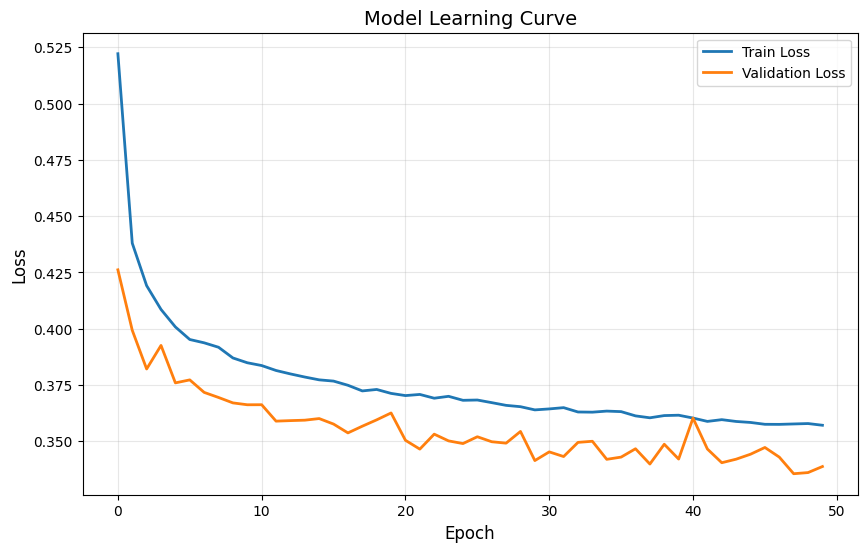

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(train_losses, label="Train Loss", linewidth=2)
plt.plot(val_losses, label="Validation Loss", linewidth=2)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("Model Learning Curve", fontsize=14)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 📈 Learning Curve Xulosasi

Yuqoridagi **Model Learning Curve** grafikasi quyidagilarni ko‘rsatadi:

- **Train Loss (ko‘k chiziq)** va **Validation Loss (to‘q sariq chiziq)** epoxlar davomida kamaymoqda.  
- Training va validation losslar bir-biriga yaqin bo‘lib, katta **overfitting yo‘qligini** ko‘rsatmoqda.  
- Model tez o‘rganishni boshlaydi va **barqaror learning pattern**ni namoyish qiladi.  
- Yakuniy epoxlarda loss qiymati past darajada barqaror bo‘lib, model **test ma’lumotlarida yaxshi umumlashadi**.  

**Xulosa:**  
- Model **trening ma’lumotlarida va validation ma’lumotlarida yaxshi ishlaydi**.  
- Performance barqaror va overfitting xavfi minimal.  
- Shu Learning Curve asosida **modelni test ma’lumotlarida baholashga tayyor** deb aytish mumkin.

# Evaluation

In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model.eval()

with torch.no_grad():

    test_logits = model(X_test_t)

    test_probs = torch.sigmoid(test_logits)

    y_pred = (test_probs >= 0.5).int().cpu().numpy().flatten()


y_true = y_test_t.cpu().numpy().flatten()


acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)


print("\nTest Metrics")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")


Test Metrics
Accuracy : 0.8310
Precision: 0.7457
Recall   : 0.8347
F1 Score : 0.7877


# Confusion Matrix

<Figure size 700x600 with 0 Axes>

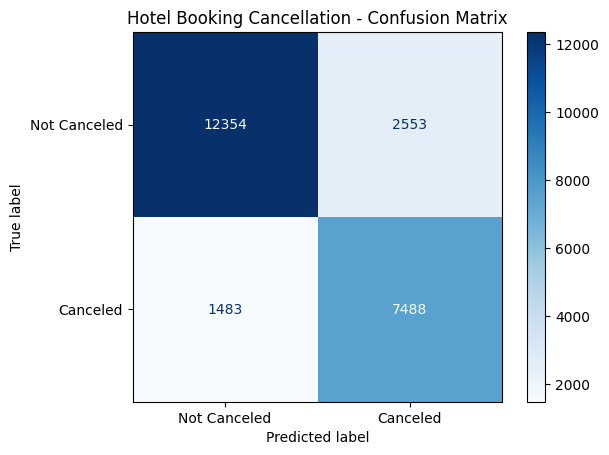

In [53]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Canceled", "Canceled"]
)

plt.figure(figsize=(7,6))
disp.plot(cmap="Blues", values_format="d")

plt.title("Hotel Booking Cancellation - Confusion Matrix")
plt.show()

In [ ]:
import torch
import os


save_path = r"C:\Users\rrasu\Desktop\Hotel-Booking-Cancellation-Prediction\Deep_Learning\Model\structured_nn_model.pt"
torch.save(model.state_dict(), save_path)
print(f"Model saqlandi: {save_path}")

Model saqlandi: C:\Users\rrasu\Desktop\Hotel-Booking-Cancellation-Prediction\Deep_Learning\Model\structured_nn_model.pt


In [55]:
import joblib

save_path_joblib = r"C:\Users\rrasu\Desktop\Hotel-Booking-Cancellation-Prediction\Deep_Learning\Model\structured_nn_model.joblib"
joblib.dump(model.state_dict(), save_path_joblib)
print(f"Model state_dict joblib bilan saqlandi: {save_path_joblib}")

Model state_dict joblib bilan saqlandi: C:\Users\rrasu\Desktop\Hotel-Booking-Cancellation-Prediction\Deep_Learning\Model\structured_nn_model.joblib
